In [3]:
import pandas as pd
from utiles import age_group_label
from utiles import income_band

In [2]:
import pandas as pd
df_customers_dummy = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E"],
    "age": [22, 35, 47, 63, 29],
    "income": [18000, 42000, 72000, 95000, 25000]
})

df_customers_dummy

,customer,age,income
0,A,22,18000
1,B,35,42000
2,C,47,72000
3,D,63,95000
4,E,29,25000


In [3]:
df_customers_dummy ["age_group_label"] = df_customers_dummy["age"].apply(age_group_label) 
df_customers_dummy

,customer,age,income,age_group_label
0,A,22,18000,NaN
1,B,35,42000,Middle
2,C,47,72000,Middle
3,D,63,95000,Senior
4,E,29,25000,NaN


In [4]:
df_customers_dummy["income_band"] = df_customers_dummy["income"].apply(income_band)
df_customers_dummy

,customer,age,income,income_band
0,A,22,18000,NaN
1,B,35,42000,Middle income
2,C,47,72000,Middle income
3,D,63,95000,High income
4,E,29,25000,NaN


In [5]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt

In [6]:
df_instacart = pd.read_parquet('../data/processed/instacart.parquet')

In [7]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 60:
        return "Middle"
    else:
        return "Senior"

df_instacart["age_group"] = df_instacart["Age"].apply(age_group)
df_instacart["age_group"].value_counts(dropna=False)

age_group
Middle    652827
Senior    470466
Young     261413
Name: count, dtype: int64

In [8]:
def order_time_band(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df_instacart["order_time_band"] = df_instacart["order_hour_of_day"].apply(order_time_band)
df_instacart["order_time_band"].value_counts(dropna=False)

order_time_band
Afternoon    669307
Morning      434015
Evening      254731
Night         26653
Name: count, dtype: int64

In [10]:
df_scores["pass_flag"] = df_scores["score"].apply( lambda x: "Pass" if x >=50 else "Fail")
df_scores

NameError: name 'df_scores' is not defined

In [19]:
def classify_price(price, low=5, high=15):
    if price <= low:
        return "Low-range product"
    elif price <= high:
        return "Mid-range product"
    else:
        return "High-range product"

classify_price(9)

'Mid-range product'

In [27]:
def price_label(row):
    if row["prices"] <= 5:
        return "Low-range product"
    elif row["prices"] <= 15:
        return "Mid-range product"
    elif row["prices"] > 15:
        return "High-range product"
    else:
        return "Not enough data"

In [28]:
df_instacart["price_range"] = df_instacart.apply(price_label, axis=1)
df_instacart["price_range"].value_counts(dropna=False)

price_range
Mid-range product     936243
Low-range product     430870
High-range product     17505
Not enough data           88
Name: count, dtype: int64

In [21]:
df_products_dummy = pd.DataFrame({
    "product": ["Milk", "Bread", "Juice", "Cheese", "Steak", "Apples"],
    "price": [2.5, 1.8, 6.2, 12.0, 24.5, 4.2]
})

df_products_dummy

,product,price
0,Milk,2.5
1,Bread,1.8
2,Juice,6.2
3,Cheese,12.0
4,Steak,24.5
5,Apples,4.2


In [25]:
df_products_dummy["price_range"] = df_products_dummy["price"].apply(classify_price)
df_products_dummy

,product,price,price_range
0,Milk,2.5,Low-range product
1,Bread,1.8,Low-range product
2,Juice,6.2,Mid-range product
3,Cheese,12.0,Mid-range product
4,Steak,24.5,High-range product
5,Apples,4.2,Low-range product


In [30]:
price_range_counts = df_instacart["price_range"].value_counts().sort_values()

price_range_counts

price_range
Not enough data           88
High-range product     17505
Low-range product     430870
Mid-range product     936243
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

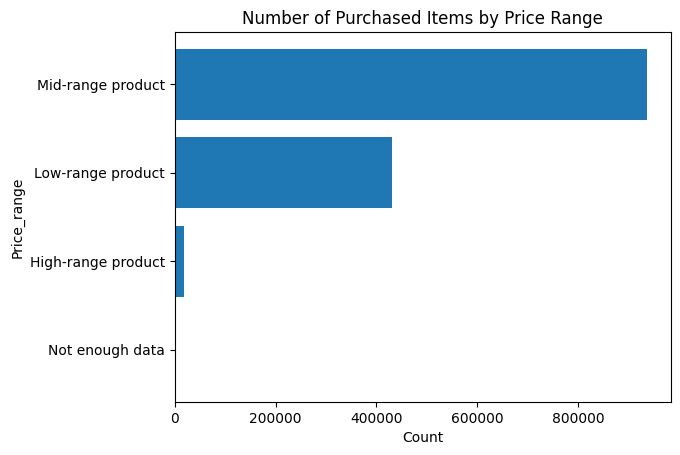

In [32]:
price_range_counts = df_instacart["price_range"].value_counts().sort_values()
plt.figure()
plt.barh(price_range_counts.index,price_range_counts.values)
plt.title("Number of Purchased Items by Price Range")
plt.xlabel("Count")
plt.ylabel("Price_range")
plt.show


In [35]:
reorder_by_price_range = (
    df_instacart
    .groupby("price_range")["reordered"]
    .mean()
    .sort_values()
)

reorder_by_price_range

price_range
High-range product    0.579092
Low-range product     0.590833
Mid-range product     0.602527
Not enough data       0.670455
Name: reordered, dtype: float64

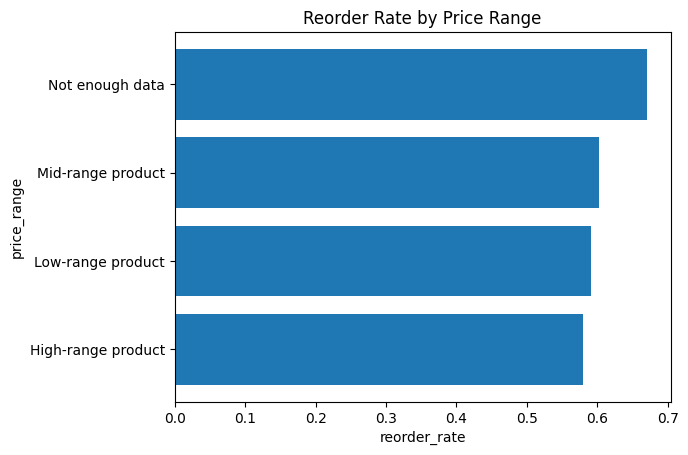

In [38]:
reorder_by_price_range = (
    df_instacart
    .groupby("price_range")["reordered"]
    .mean()
    .sort_values()
)




plt.figure()
plt.barh(reorder_by_price_range.index, reorder_by_price_range.values)
plt.title("Reorder Rate by Price Range")
plt.xlabel("reorder_rate")
plt.ylabel("price_range")
plt.show()

In [39]:
orders_time_band = (
    df_instacart[["order_id", "order_time_band"]]
    .drop_duplicates()
    .groupby("order_time_band")
    .size()
    .sort_values()
)

orders_time_band

order_time_band
Night         2507
Evening      24275
Morning      41068
Afternoon    63359
dtype: int64

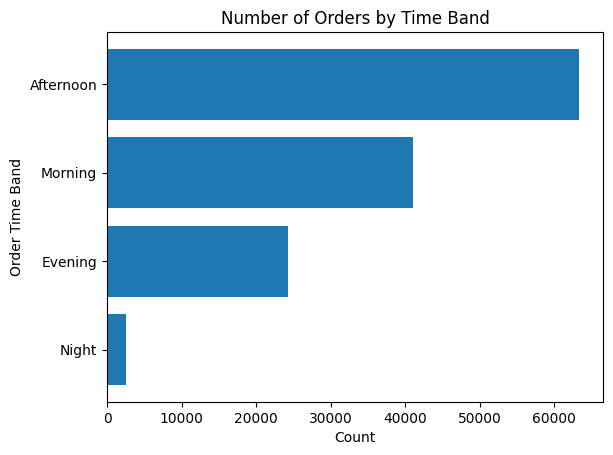

In [40]:
orders_time_band = (
    df_instacart[["order_id", "order_time_band"]]
    .drop_duplicates()
    .groupby("order_time_band")
    .size()
    .sort_values()
)

plt.figure()
plt.barh(orders_time_band.index, orders_time_band.values)
plt.title("Number of Orders by Time Band")
plt.xlabel("Count")
plt.ylabel("Order Time Band")
plt.show()

In [41]:
reorder_by_order_time_band = (
    df_instacart.groupby("order_time_band")["reordered"]
    .mean()
    .sort_values
)
reorder_by_order_time_band

<bound method Series.sort_values of order_time_band
Afternoon    0.588812
Evening      0.593630
Morning      0.617444
Night        0.584850
Name: reordered, dtype: float64>

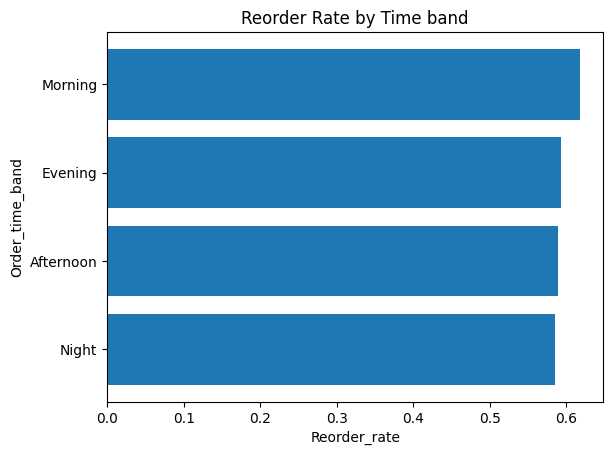

In [44]:
reorder_by_order_time_band = (
    df_instacart.groupby("order_time_band")["reordered"]
    .mean()
    .sort_values()
)


plt.figure()
plt.barh(reorder_by_order_time_band.index, reorder_by_order_time_band.values)
plt.title("Reorder Rate by Time band")
plt.xlabel("Reorder_rate")
plt.ylabel("Order_time_band")
plt.show()          